### Basic ChatBot (Graph API)

In [ ]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END

from langgraph.graph.message import add_messages # reducers - to append the message 


In [ ]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = init_chat_model("groq:llama-3.3-70b-versatile")


In [8]:
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10651c980>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10651d010>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
"Node functionality"
def chatBot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [16]:
# Building Graph

graph_builder = StateGraph(State)

# adding nodes to the graph
graph_builder.add_node("llmchatBot",chatBot)

# adding edges to the graph
graph_builder.add_edge(START, "llmchatBot")
graph_builder.add_edge("llmchatBot", END)

# compile the graph
graph = graph_builder.compile()

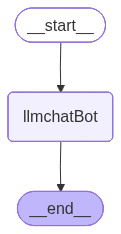

In [17]:
# visulazing the graph

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [21]:
response = graph.invoke({"messages": ["Hello, how are you?"]})

In [ ]:
response["messages"] 
response["messages"][-1] # last message in the list of messages
response["messages"][-1].content

"Hello, I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?"

In [27]:
for event in graph.stream({"messages": ["Can you tell me about today's news in India?"]}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm a large language model, I don't have real-time access to current events or news. My training data only goes up to 2023, and I don't have the ability to browse the internet or access current news.

However, I can suggest some ways for you to stay up-to-date with the latest news in India:

1. **Online news websites**: You can visit popular Indian news websites such as The Times of India, Hindustan Times, India Today, or The Indian Express to get the latest news.
2. **News apps**: Download news apps like Google News, Flipboard, or Inshorts to get curated news updates from various sources.
3. **Social media**: Follow Indian news channels, journalists, or influencers on social media platforms like Twitter, Facebook, or Instagram to stay informed.
4. **TV news channels**: Watch Indian news channels like NDTV, CNN-News18, or Republic TV to get the latest updates.

Some popular news topics in India in 2023 (based on my training data) included:

* Politics: Elections, government policies, a